In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*load and inspect the dataset...*

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/autoassess_dataset/part_price_prediction/ikman_all_parts_cleaned.csv")

df.shape
df.head()

,part,listing_title,price,location,url,price_lkr,title_lower
0,bumper,Suzuki swift RS buffer for sale,"Rs 55,000","Gampaha, Auto Parts & Accessories",https://ikman.lk/en/ad/suzuki-swift-rs-buffer-...,55000,suzuki swift rs buffer for sale
1,bumper,Mazda Demio DE3FS rear Bumper for sale,"Rs 26,000","Colombo, Auto Parts & Accessories",https://ikman.lk/en/ad/mazda-demio-de3fs-rear-...,26000,mazda demio de3fs rear bumper for sale
2,bumper,Mazda Demio DE3FS Front Bumper Panel for sale,"Rs 30,000","Colombo, Auto Parts & Accessories",https://ikman.lk/en/ad/mazda-demio-de3fs-front...,30000,mazda demio de3fs front bumper panel for sale
3,bumper,95 FX Front Bumper (2024) for sale,"Rs 110,000","Colombo, Auto Parts & Accessories",https://ikman.lk/en/ad/95-fx-front-bumper-2024...,110000,95 fx front bumper (2024) for sale
4,bumper,Axio 161 Rear Bumper for sale,"Rs 32,000","Colombo, Auto Parts & Accessories",https://ikman.lk/en/ad/axio-161-rear-bumper-fo...,32000,axio 161 rear bumper for sale


In [ ]:
print("="*60)
print("DATASET SHAPE")
print("="*60)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("FIRST 5 RECORDS")
print("="*60)
print(df.head())

print("\n" + "="*60)
print("LAST 5 RECORDS")
print("="*60)
print(df.tail())

DATASET SHAPE
Rows: 1133
Columns: 7

COLUMN NAMES
['part', 'listing_title', 'price', 'location', 'url', 'price_lkr', 'title_lower']

DATA TYPES
part             object
listing_title    object
price            object
location         object
url              object
price_lkr         int64
title_lower      object
dtype: object

FIRST 5 RECORDS
     part                                  listing_title       price  \
0  bumper                Suzuki swift RS buffer for sale   Rs 55,000   
1  bumper         Mazda Demio DE3FS rear Bumper for sale   Rs 26,000   
2  bumper  Mazda Demio DE3FS Front Bumper Panel for sale   Rs 30,000   
3  bumper             95 FX Front Bumper (2024) for sale  Rs 110,000   
4  bumper                  Axio 161 Rear Bumper for sale   Rs 32,000   

                            location  \
0  Gampaha, Auto Parts & Accessories   
1  Colombo, Auto Parts & Accessories   
2  Colombo, Auto Parts & Accessories   
3  Colombo, Auto Parts & Accessories   
4  Colombo, Auto Parts &

*unique classes...*

In [ ]:
print("="*60)
print("UNIQUE PART CLASSES")
print("="*60)
print(df["part"].unique())

print("\nTotal unique part categories:", df["part"].nunique())

UNIQUE PART CLASSES
['bumper' 'buffer' 'front buffer' 'rear buffer' 'door panel' 'headlight'
 'tail light' 'rear light' 'front guard' 'rear guard' 'bonnet'
 'dickey door' 'side mirror' 'windscreen']

Total unique part categories: 14


*frequency distribution...*

In [ ]:
print("="*60)
print("PART DISTRIBUTION")
print("="*60)
print(df["part"].value_counts())

PART DISTRIBUTION
part
door panel      124
headlight       113
bonnet          113
buffer          111
windscreen      111
bumper          105
rear light      104
dickey door     103
tail light       97
side mirror      63
rear buffer      42
front buffer     26
front guard      11
rear guard       10
Name: count, dtype: int64


*price statistics...*

In [ ]:
print("="*60)
print("PRICE SUMMARY STATISTICS")
print("="*60)
print(df["price_lkr"].describe())

PRICE SUMMARY STATISTICS
count      1133.000000
mean      53155.810238
std       58096.083686
min        6000.000000
25%       18000.000000
50%       35000.000000
75%       65000.000000
max      450000.000000
Name: price_lkr, dtype: float64


*duplicated records...*

In [ ]:
print("="*60)
print("DUPLICATE URL COUNT")
print("="*60)
print(df.duplicated(subset=["url"]).sum())

DUPLICATE URL COUNT
0


*location distribution...*

In [ ]:
print("="*60)
print("TOP LOCATIONS")
print("="*60)
print(df["location"].value_counts().head(10))

TOP LOCATIONS
location
Colombo, Auto Parts & Accessories         820
Gampaha, Auto Parts & Accessories         200
Kurunegala, Auto Parts & Accessories       93
Kalutara, Auto Parts & Accessories         13
Anuradhapura, Auto Parts & Accessories      3
Kandy, Auto Parts & Accessories             2
Jaffna, Auto Parts & Accessories            1
Galle, Auto Parts & Accessories             1
Name: count, dtype: int64


*normalize part categories...*

In [ ]:
PART_MAP = {
    "buffer": "bumper",
    "front buffer": "bumper",
    "rear buffer": "bumper",
    "rear light": "taillight",
    "tail light": "taillight",
    "front guard": "fender",
    "rear guard": "fender",
    "bonnet": "hood",
    "dickey door": "trunk"
}

df["part"] = df["part"].replace(PART_MAP)

print("="*60)
print("UPDATED UNIQUE PART CLASSES")
print("="*60)
print(df["part"].unique())

print("\nUPDATED PART DISTRIBUTION")
print(df["part"].value_counts())

UPDATED UNIQUE PART CLASSES
['bumper' 'door panel' 'headlight' 'taillight' 'fender' 'hood' 'trunk'
 'side mirror' 'windscreen']

UPDATED PART DISTRIBUTION
part
bumper         284
taillight      201
door panel     124
headlight      113
hood           113
windscreen     111
trunk          103
side mirror     63
fender          21
Name: count, dtype: int64


*price distribution analysis before outlier handling...*

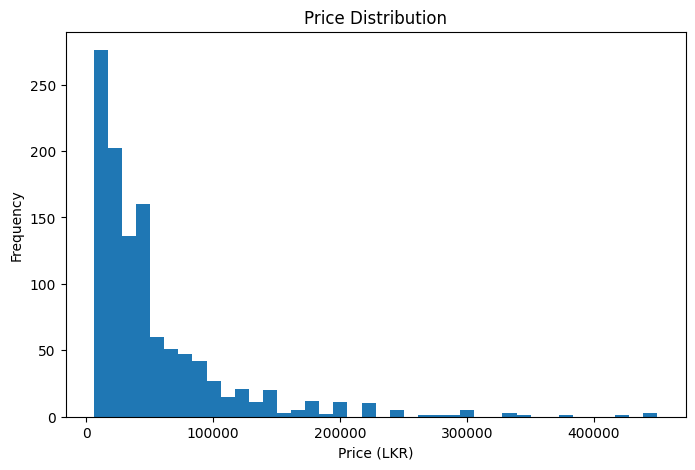

Skewness: 2.9153151336355974


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price_lkr"], bins=40)
plt.title("Price Distribution")
plt.xlabel("Price (LKR)")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df["price_lkr"].skew())

*reducing the price class using log transformation...*

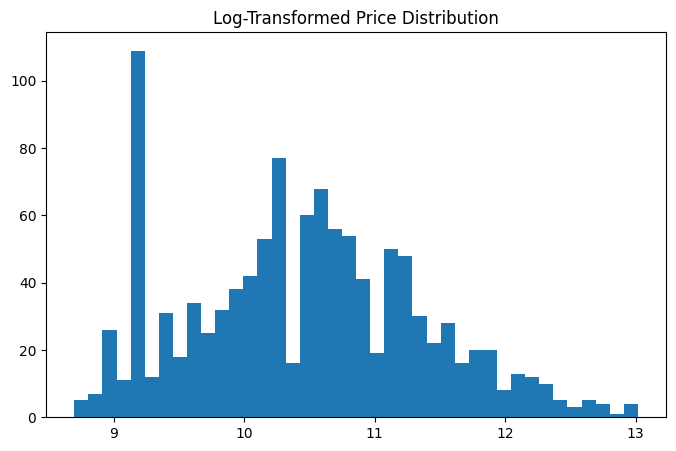

Log skewness: 0.24647917484670268


In [ ]:
import numpy as np

df["log_price"] = np.log(df["price_lkr"])

plt.figure(figsize=(8,5))
plt.hist(df["log_price"], bins=40)
plt.title("Log-Transformed Price Distribution")
plt.show()

print("Log skewness:", df["log_price"].skew())

*extract the vehicle make from the title...*

In [ ]:
df["title_lower"] = df["listing_title"].str.lower()

In [ ]:
COMMON_MAKES = [
    "toyota", "honda", "nissan", "suzuki", "bmw", "audi",
    "mercedes", "benz", "renault", "daihatsu", "micro",
    "mini cooper", "range rover", "defender", "land rover",
    "jeep", "tata", "kia", "mazda", "mahindra", "perodua",
    "hyundai", "lexus", "vega", "byd", "ford",
    "mitsubishi", "mg", "baw", "gac"
]

def extract_make(title):
    for make in COMMON_MAKES:
        if make in title:
            return make
    return "other"

df["make"] = df["title_lower"].apply(extract_make)

print(df["make"].value_counts())

make
toyota         242
other          212
honda          147
suzuki         122
nissan         109
bmw             70
audi            49
mitsubishi      28
mercedes        28
mazda           26
byd             20
daihatsu        20
range rover     18
land rover      14
benz            11
micro            3
ford             3
mg               3
hyundai          2
mini cooper      2
defender         2
mahindra         1
gac              1
Name: count, dtype: int64


*feature encording...*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df[["part", "make"]]
y = df["log_price"]

*train & test split...*

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

*specifing the model...*

In [ ]:
categorical_features = ["part", "make"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

*train the model...*

In [ ]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.7008312288545325
RMSE: 0.8880541263497838
R2: -0.020114209349531453


*convert predictions back to price scale...*

In [ ]:
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)

print("Actual MAE (LKR):", mean_absolute_error(y_test_actual, y_pred_actual))

Actual MAE (LKR): 30205.60149374828


***Linear regression using only categorical features (part and make) was insufficient to model price variation, as indicated by negative R² values. This suggests price variability depends on finer-grained vehicle specifications...***



***Therefore trying out with Random Forest Regressor...***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

y_pred_rf_actual = np.exp(y_pred_rf)
print("Actual MAE (LKR):", mean_absolute_error(y_test_actual, y_pred_rf_actual))

MAE: 0.6474594364470306
RMSE: 0.8356646807966291
R2: 0.09669582354949025
Actual MAE (LKR): 27674.482377996013


*extract the vehicle model from the title...*

In [ ]:
import re

# clean title just in case
df["title_lower"] = df["listing_title"].str.lower()

# extract model: word after make
def extract_model(row):
    make = row["make"]
    title = row["title_lower"]

    if make == "other":
        return "unknown"

    # find make position
    pattern = rf"{make}\s+([a-z0-9\-]+)"
    match = re.search(pattern, title)

    if match:
        return match.group(1)
    else:
        return "unknown"

df["model"] = df.apply(extract_model, axis=1)

print(df[["make", "model", "listing_title"]].head(15))

          make      model                                      listing_title
0       suzuki      swift                    Suzuki swift RS buffer for sale
1        mazda      demio             Mazda Demio DE3FS rear Bumper for sale
2        mazda      demio      Mazda Demio DE3FS Front Bumper Panel for sale
3        other    unknown                 95 FX Front Bumper (2024) for sale
4        other    unknown                      Axio 161 Rear Bumper for sale
5   mitsubishi  outlander  Mitsubishi Outlander GG2W Front Bumper Panel f...
6       toyota      yaris          Toyota Yaris Ksp210 Front Bumper for sale
7       toyota      roomy  Toyota Roomy Tank Rear Buffer Bumper Bodykit f...
8        other    unknown                     Axio 141 Front Bumper for sale
9        other    unknown           Yaris Cross Front Bumper (2025) for sale
10       other    unknown                          121 Front Bumper for sale
11        audi         a1                       Audi A1 rear bumper for sale

In [ ]:
print("Unique models count:", df["model"].nunique())
print("\nTop 20 models:")
print(df["model"].value_counts().head(20))

Unique models count: 239

Top 20 models:
model
unknown    216
fit         52
prius       36
wagon       32
vitz        30
aqua        26
swift       24
vezel       23
axio        19
civic       17
every       16
benz        16
march       15
insight     15
demio       14
alto        14
x           14
a1          13
hustler     12
hilux       11
Name: count, dtype: int64


*group the rare found models into a other models...*

In [ ]:
model_counts = df["model"].value_counts()

rare_models = model_counts[model_counts < 10].index

df["model"] = df["model"].replace(rare_models, "other_model")

print("Final model categories:", df["model"].nunique())

Final model categories: 24


*retrain random forest with the new features...*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df[["part", "make", "model"]]
y = np.log1p(df["price_lkr"])

categorical_features = ["part", "make", "model"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# Convert MAE back to LKR
actual_mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred)))
print("Actual MAE (LKR):", actual_mae)

MAE: 0.6122419360422552
RMSE: 0.8110421287254607
R2: 0.14907945534152856
Actual MAE (LKR): 26356.679178342492


***hyperparameter tuning...***

*defining parameter grid...*

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

param_grid = {
    "regressor__n_estimators": [200, 300],
    "regressor__max_depth": [None, 15, 25],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}

rf_model = RandomForestRegressor(random_state=42)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", rf_model)
])

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'regressor__max_depth': 25, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 300}


*evaluate tuned model...*

In [ ]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned MAE:", mae)
print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)

actual_mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred_tuned)))
print("Tuned Actual MAE (LKR):", actual_mae)

Tuned MAE: 0.6232771749333871
Tuned RMSE: 0.7967368954266929
Tuned R2: 0.17883195680142483
Tuned Actual MAE (LKR): 26349.77508805309


*extract variant codes (nhp10, gp1, de3fs, etc..)...*

In [ ]:
import re

def extract_variant(title):
    # find alphanumeric codes with at least one digit
    matches = re.findall(r"\b[a-z]{1,4}[0-9]{1,4}[a-z0-9]*\b", title)
    if matches:
        return matches[0]
    return "no_variant"

df["variant"] = df["title_lower"].apply(extract_variant)

print("Top 20 variants:")
print(df["variant"].value_counts().head(20))

Top 20 variants:
variant
no_variant    529
gp1            20
gp5            20
nhp10          17
a1             13
ksp130         13
ze2            13
da17           12
de3fs          12
gp2            12
mh55s          11
a4             11
q2              9
k12             9
ksp90           9
zc71s           9
x1              8
a3              8
g11             8
da64            7
Name: count, dtype: int64


*remove rare variants...*

In [ ]:
variant_counts = df["variant"].value_counts()

rare_variants = variant_counts[variant_counts < 8].index

df["variant"] = df["variant"].replace(rare_variants, "other_variant")

print("Final variant categories:", df["variant"].nunique())

Final variant categories: 20


*retrain model with variant...*

In [ ]:
X = df[["part", "make", "model", "variant"]]
y = np.log1p(df["price_lkr"])

categorical_features = ["part", "make", "model", "variant"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", rf_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_variant = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_variant)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_variant))
r2 = r2_score(y_test, y_pred_variant)

print("With Variant - MAE:", mae)
print("With Variant - RMSE:", rmse)
print("With Variant - R2:", r2)

actual_mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred_variant)))
print("With Variant - Actual MAE (LKR):", actual_mae)

With Variant - MAE: 0.6523340172322178
With Variant - RMSE: 0.8650528823003276
With Variant - R2: 0.03197294166331843
With Variant - Actual MAE (LKR): 28061.706984972738


*train final model again...*

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df[["part", "make", "model"]]
y = np.log1p(df["price_lkr"])

categorical_features = ["part", "make", "model"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", rf_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE (log):", mean_absolute_error(y_test, y_pred))

actual_mae = np.mean(np.abs(np.expm1(y_test) - np.expm1(y_pred)))
print("MAE (LKR):", actual_mae)

R2: 0.13468707950303382
MAE (log): 0.6426496395674226
MAE (LKR): 27106.733458263865


*save final model...*

In [ ]:
import joblib

joblib.dump(pipeline, "autoassess_price_model.pkl")

print("Model saved successfully.")

Model saved successfully.


*extract importance for later justifications...*

              feature  importance
2         part_fender    0.064117
11           make_bmw    0.052679
5    part_side mirror    0.046343
28   make_range rover    0.044814
12           make_byd    0.043519
10          make_benz    0.042411
8     part_windscreen    0.041686
1     part_door panel    0.041070
0         part_bumper    0.040817
6      part_taillight    0.038215
46  model_other_model    0.035402
4           part_hood    0.035059
3      part_headlight    0.031932
19    make_land rover    0.030322
21      make_mercedes    0.024404


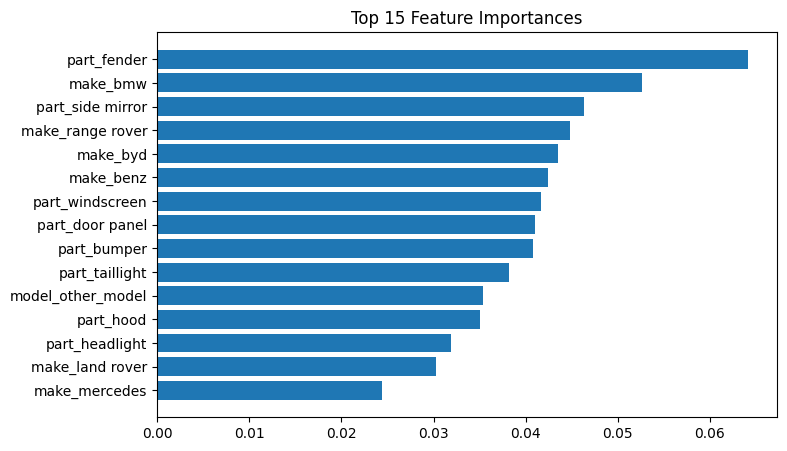

In [ ]:
import matplotlib.pyplot as plt

feature_names = pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

importances = pipeline.named_steps["regressor"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

***testing the model...***

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Load model
model = joblib.load("autoassess_price_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
test_samples = pd.DataFrame([
    {
        "part": "bumper",
        "make": "toyota",
        "model": "aqua",
        "position": "front"
    },
    {
        "part": "headlight",
        "make": "bmw",
        "model": "x3",
        "position": "front"
    },
    {
        "part": "windscreen",
        "make": "honda",
        "model": "fit",
        "position": "unknown"
    }
])

# Predict log price
pred_log = model.predict(test_samples)

# Convert back to LKR
pred_price = np.expm1(pred_log)

for i, price in enumerate(pred_price):
    print(f"Prediction {i+1}: Rs. {int(price)}")

Prediction 1: Rs. 35046
Prediction 2: Rs. 58174
Prediction 3: Rs. 65224


*test on unseen vehicle models...*

In [ ]:
new_test = pd.DataFrame([{
    "part": "bumper",
    "make": "toyota",
    "model": "unknown_model_xyz",
    "position": "front"
}])

pred_log = model.predict(new_test)
print("Unseen model prediction:", int(np.expm1(pred_log)[0]))

Unseen model prediction: 35261
